In [ ]:
from typing import TypedDict, List, Dict

class InterviewState(TypedDict):
    # 고정 정보
    resume_text: str
    resume_summary: str
    resume_keywords: List[Dict[str, str]]     # 기술명과 분류 함께 저장
    job_match_score: Dict[str, str]           # 직무 평가 결과
    core_strengths:List[str]                  # 핵심 강점 3가지
    career_path_suggestion: Dict[str, str]      # 커리어 성장 방향 예측
    resume_reliability: Dict[str, str]          # 이력서 신뢰도 평가
    question_strategy: Dict[str, Dict]

    # 인터뷰 로그
    current_question: str
    current_answer: str
    current_strategy: str
    conversation: List[Dict[str, str]]
    evaluation : List[Dict[str, str]]
    next_step : str

In [ ]:
# 파일에서 읽어 State 초기화
file_path = path + 'Resume_sample.pdf'

# 텍스트 추출
resume_text = extract_text_from_file(file_path)
resume_text

'<이력서> \n홍길동 (Gil-dong Hong) \n이메일: gildong.hong@example.com \n전화번호: 010-1234-5678 \n학력 \n- 한국대학교 전기정보공학부 학사 (2018.03 ~ 2022.02) \n  GPA: 3.91 / 4.3, 전공과목: 머신러닝, 데이터마이닝, 신호처리 \n경력 \n- KT, AI 연구소 인턴 (2021.07 ~ 2021.12) \n  • OCR 기반 문서 처리 시스템 고도화 \n  • Tesseract + 딥러닝 후처리 파이프라인 설계 \n  • 사내 법률문서 정제 정확도 12% 개선 \n- 빅데이터 학생연합 (BDSA) 기술부장 (2020.03 ~ 2021.02) \n  • Python 기반 크롤러 및 Flask API 개발 \n  • 공공데이터 기반 부동산 가격 예측 프로젝트 리드 \n프로젝트 \n- AI 면접관 시스템 개발 (졸업 과제) \n  • OpenAI GPT + Streamlit + FAISS 기반 질문-응답 시스템 구현 \n  • 이력서 기반 질문 자동 생성 + 답변 피드백 제공 \n- 딥러닝 기반 교통량 예측 (교과목 프로젝트) \n  • LSTM 기반 모델 + 서울시 교통데이터 \n  • MAE 15% 이하로 개선 \n기술 스택 \n- Python, PyTorch, TensorFlow, OpenCV \n- MySQL, MongoDB, Git, Docker \n\n- 영어 (TOEIC 915, 영어면접 가능) \n수상 및 자격 \n- SKT Big Data Challenge 2021 장려상 \n- 정보처리기사 (2022.05 취득) \n기타 \n- Github: github.com/gildong-ai \n- 블로그: blog.naver.com/gildong_dev \n \n \n\n<자기소개서> \n1. 본인 성격의 강/약점에 대해서 실제 사례를 포함하여 작성해 주세요. \n무엇인가 한번 빠져들면 해결하거나 성취할 때까지 모든 열정/노력을 쏟아붓는 성격으\n로, 그 과정에서 큰 어려

In [ ]:
# 테스트를 위한 초기 상태 구성
initial_state: InterviewState = {
    "resume_text": resume_text,
    "resume_summary": '',
    "resume_keywords": [],
    "job_match_score": {},
    "core_strengths": [],
    "career_path_suggestion": {},
    "resume_reliability": {},
    "question_strategy": {},

    "current_question": '',
    "current_answer": '',
    "current_strategy": '',
    "conversation": [],
    "evaluation": [],
    "next_step" : ''
}

initial_state

{'resume_text': '<이력서> \n홍길동 (Gil-dong Hong) \n이메일: gildong.hong@example.com \n전화번호: 010-1234-5678 \n학력 \n- 한국대학교 전기정보공학부 학사 (2018.03 ~ 2022.02) \n  GPA: 3.91 / 4.3, 전공과목: 머신러닝, 데이터마이닝, 신호처리 \n경력 \n- KT, AI 연구소 인턴 (2021.07 ~ 2021.12) \n  • OCR 기반 문서 처리 시스템 고도화 \n  • Tesseract + 딥러닝 후처리 파이프라인 설계 \n  • 사내 법률문서 정제 정확도 12% 개선 \n- 빅데이터 학생연합 (BDSA) 기술부장 (2020.03 ~ 2021.02) \n  • Python 기반 크롤러 및 Flask API 개발 \n  • 공공데이터 기반 부동산 가격 예측 프로젝트 리드 \n프로젝트 \n- AI 면접관 시스템 개발 (졸업 과제) \n  • OpenAI GPT + Streamlit + FAISS 기반 질문-응답 시스템 구현 \n  • 이력서 기반 질문 자동 생성 + 답변 피드백 제공 \n- 딥러닝 기반 교통량 예측 (교과목 프로젝트) \n  • LSTM 기반 모델 + 서울시 교통데이터 \n  • MAE 15% 이하로 개선 \n기술 스택 \n- Python, PyTorch, TensorFlow, OpenCV \n- MySQL, MongoDB, Git, Docker \n\n- 영어 (TOEIC 915, 영어면접 가능) \n수상 및 자격 \n- SKT Big Data Challenge 2021 장려상 \n- 정보처리기사 (2022.05 취득) \n기타 \n- Github: github.com/gildong-ai \n- 블로그: blog.naver.com/gildong_dev \n \n \n\n<자기소개서> \n1. 본인 성격의 강/약점에 대해서 실제 사례를 포함하여 작성해 주세요. \n무엇인가 한번 빠져들면 해결하거나 성취할 때까지 모든 열정/노력을 쏟아붓는 성격으

### (3) Resume 분석

* 목적
    * 개인화된 질문을 뽑기 위한 이력서 핵심 내용 및 키워드 도출
    * 질문 전략을 수립하기 위한 기본 자료로 사용
* 입출력
    * 입력 : 이력서/자소서 text
    * 출력 : 핵심 요약 str, 주요 키워드 List
* 처리
    * 프롬프트 템플릿 구성하여 LLM 활용한 처리
    * 요약과 키워드 도출을 한꺼번에 할 수도 있고, 단계를 나눠서 요약 따로, 키워드 도출 따로 진행도 가능


In [ ]:
def analyze_resume(state: InterviewState) -> InterviewState:

    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.4)

    prompt = ChatPromptTemplate.from_template("""
    당신은 인사(HR) 전문가이자 커리어 분석가입니다.
    아래의 이력서 내용을 분석하여 다음 항목을 JSON 형식으로 출력하세요.

    분석 목표:
    1️. 핵심 요약 (STAR 방식)
        - Situation, Task, Action, Result 순으로 3문장 이내 요약
    2️. 기술 스킬 구조화
        - 각 기술에 대해 {{"기술": "...", "분류": "..."}} 형식으로 제시
        - 분류 예시: 언어, 프레임워크, 데이터베이스, 도구, 기타
    3️. 예상 직무 및 적합도 평가
        - 이력서 내용을 기반으로 예상 직무 1개 추정
        - 해당 직무에 대한 적합도(%)와 평가 요약 제공
        예시:
        "job_match_score": {{"예상 직무": "AI 개발자", "적합도": "88%", "평가": "데이터 처리 및 모델링 경험 우수"}}
    4️. 핵심 강점 3가지 도출
    5️. 커리어 성장 방향 예측 (Career Path Insight)
        - 이력서에 나타난 기술/경험을 바탕으로 향후 발전 가능성이 높은 직무나 산업 방향을 예측
        예시:
        {{"예상 성장 방향": "데이터 엔지니어 → AI 리서처", "설명": "데이터 전처리 및 모델링 경험이 풍부해 AI 연구개발로 성장 가능"}}
    6️. 이력서 신뢰도 평가 (Resume Authenticity Check)
        - 이력서 내 구체성, 근거, 수치, 문체 일관성을 고려해 신뢰도를 %로 평가
        - 간단한 설명 포함
        예시:
        {{"점수": "82%", "평가": "성과 근거가 명확하고 구체적이지만 일부 내용이 포괄적임"}}

    --- 이력서 내용 ---
    {resume_text}
    --------------------

    출력 형식 (JSON만 반환, 코드블록 금지):
    {{
      "resume_summary": "...",
      "resume_keywords": [{{"기술": "...", "분류": "..."}}],
      "job_match_score": {{"예상 직무": "...", "적합도": "...", "평가": "..."}},
      "core_strengths": ["...", "...", "..."],
      "career_path_suggestion": {{"예상 성장 방향": "...", "설명": "..."}},
      "resume_reliability": {{"점수": "...", "평가": "..."}}
    }}
    """)

    chain = prompt | llm
    response = chain.invoke({"resume_text": state.get("resume_text", "")})
    result_text = response.content.strip()


    try:
        result = json.loads(result_text)
        resume_summary = result.get("resume_summary", "")
        resume_keywords = result.get("resume_keywords", [])
        job_match_score = result.get("job_match_score", {})
        core_strengths = result.get("core_strengths", [])
        career_path_suggestion = result.get("career_path_suggestion", {})
        resume_reliability = result.get("resume_reliability", {})
    except Exception:
        resume_summary = result_text
        resume_keywords = []
        job_match_score, core_strengths = {}, []
        career_path_suggestion, resume_reliability = {}, {}

    return {
        **state,
        "resume_summary": resume_summary,
        "resume_keywords": resume_keywords,
        "job_match_score": job_match_score,
        "core_strengths": core_strengths,
        "career_path_suggestion": career_path_suggestion,
        "resume_reliability": resume_reliability,
    }

In [ ]:
updated_state = analyze_resume(initial_state)

print("이력서 요약:\n", updated_state["resume_summary"])

print("\n주요 키워드:")
if updated_state["resume_keywords"]:
    for k in updated_state["resume_keywords"]:
        print(f" - {k.get('기술', '')} ({k.get('분류', '')})")
else:
    print(" - 키워드 분석 결과 없음")

print("\n직무 적합도:")
if updated_state["job_match_score"]:
    print(f" - 예상 직무: {updated_state['job_match_score'].get('예상 직무', 'N/A')}")
    print(f" - 적합도: {updated_state['job_match_score'].get('적합도', 'N/A')}")
    print(f" - 평가: {updated_state['job_match_score'].get('평가', 'N/A')}")
else:
    print(" - 직무 분석 결과 없음")

print("\n핵심 강점:")
if updated_state["core_strengths"]:
    for s in updated_state["core_strengths"]:
        print(f" - {s}")
else:
    print(" - 핵심 강점 분석 결과 없음")

print("\n커리어 성장 방향:")
if updated_state["career_path_suggestion"]:
    print(f" - 예상 성장 방향: {updated_state['career_path_suggestion'].get('예상 성장 방향', 'N/A')}")
    print(f" - 설명: {updated_state['career_path_suggestion'].get('설명', 'N/A')}")
else:
    print(" - 커리어 성장 방향 분석 결과 없음")

print("\n이력서 신뢰도:")
if updated_state["resume_reliability"]:
    print(f" - 점수: {updated_state['resume_reliability'].get('점수', 'N/A')}")
    print(f" - 평가: {updated_state['resume_reliability'].get('평가', 'N/A')}")
else:
    print(" - 신뢰도 평가 결과 없음")


이력서 요약:
 In an internship at KT's AI research lab, I improved the accuracy of a document processing system by 12% through designing a deep learning post-processing pipeline. Leading a project on real estate price prediction, I developed a Python-based crawler and Flask API to analyze public data. My graduation project involved creating an AI interview system that utilized OpenAI's GPT to automate question generation and provide feedback.

주요 키워드:
 - Python (언어)
 - PyTorch (프레임워크)
 - TensorFlow (프레임워크)
 - OpenCV (기타)
 - MySQL (데이터베이스)
 - MongoDB (데이터베이스)
 - Git (도구)
 - Docker (도구)

직무 적합도:
 - 예상 직무: 백엔드 개발자
 - 적합도: 85%
 - 평가: 서버 개발 및 데이터 처리 경험이 풍부하며, Python 및 관련 기술 스택에 대한 이해도가 높음

핵심 강점:
 - 문제 해결 능력
 - 데이터 분석 및 처리 경험
 - 프로그래밍에 대한 열정과 지속적인 학습 의지

커리어 성장 방향:
 - 예상 성장 방향: 백엔드 개발자 → AI 엔지니어
 - 설명: 서버 개발 및 AI 관련 프로젝트 경험을 바탕으로 AI 기술을 활용한 서비스 개발로 성장 가능

이력서 신뢰도:
 - 점수: 90%
 - 평가: 구체적인 성과와 프로젝트 경험이 명확하게 기술되어 있으며, 일관된 문체를 유지하고 있음


### (4) 질문 전략 수립

* 목적 : 개인화된 질문을 뽑기 위한 질문 전략 수립
* 입출력
    * 입력 : 핵심 요약 str, 주요 키워드 List
    * 출력 : 3가지 분야에 대한 전략 수립(질문 방향, 예시 질문)
* 처리 : 프롬프트 템플릿 구성하여 LLM 활용한 처리
* 전략 수립 예시
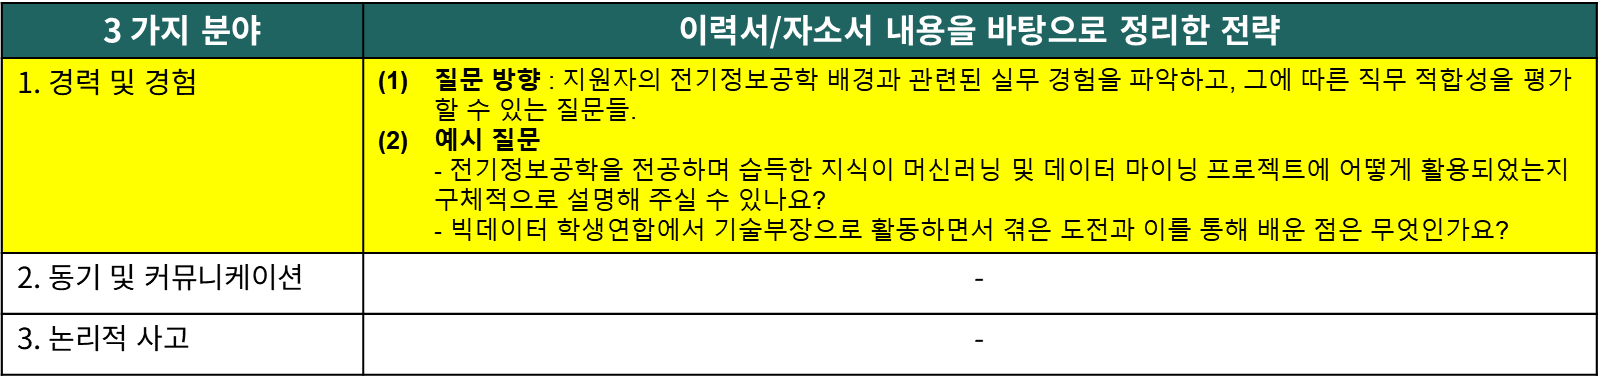

In [ ]:
def generate_question_strategy(state: InterviewState) -> InterviewState:

    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)

    used_strategy = state.get("current_strategy", "")
    all_strategies = ["경력 및 경험", "동기 및 커뮤니케이션", "논리적 사고 및 문제 해결",
                      "성장 가능성 및 학습 태도", "진위 검증 및 구체성 평가"]

    available_strategies = [s for s in all_strategies if s != used_strategy]

    if state.get("next_step", "") == "new_question":
        print(f"새로운 질문 전략 생성: 이전 전략 '{used_strategy}' 제외하고 진행합니다.")
        print(f"남은 전략 후보: {available_strategies}\n")

    prompt = ChatPromptTemplate.from_template("""
    당신은 전문 HR 면접관입니다.
    아래의 이력서 분석 결과를 참고하여, 지원자에게 적합한 맞춤형 면접 질문 전략을 수립하세요.

    --- 이력서 요약 ---
    {resume_summary}

    --- 주요 키워드 ---
    {resume_keywords}

    --- 예상 직무 및 적합도 ---
    {job_match_score}

    --- 커리어 성장 방향 ---
    {career_path_suggestion}

    --- 이력서 신뢰도 ---
    {resume_reliability}

    고려할 전략 분야:
    {available_strategies}

    면접 질문 전략은 총 5가지 영역으로 구성합니다:
    1️. 경력 및 경험 (Career Experience)
        - 실무 경험, 프로젝트, 전공 활용 능력
    2️. 동기 및 커뮤니케이션 (Motivation & Collaboration)
        - 지원 동기, 팀워크, 협업 능력
    3️. 논리적 사고 및 문제 해결 (Logical Thinking)
        - 사고 구조, 문제 분석, 해결 과정
    4️. 성장 가능성 및 학습 태도 (Growth Potential)
        - 이력서에서 보이는 향후 성장 방향을 기반으로
    5️. 진위 검증 및 구체성 평가 (Authenticity & Detail)
        - 신뢰도 평가 결과를 기반으로 진위/구체성 확인 질문

    각 항목별로 아래 형식으로 출력하세요 (코드블록 금지):

    {{
      "경력 및 경험": {{
        "질문 방향": "지원자의 실무 경험과 전공 적용 능력을 검증",
        "예시 질문": ["예시1", "예시2", "예시3"]
      }},
      "동기 및 커뮤니케이션": {{
        "질문 방향": "협업 및 동기 부여 관련 질문",
        "예시 질문": ["예시1", "예시2"]
      }},
      "논리적 사고 및 문제 해결": {{
        "질문 방향": "논리적 사고력과 문제 해결 접근을 평가",
        "예시 질문": ["예시1", "예시2"]
      }},
      "성장 가능성 및 학습 태도": {{
        "질문 방향": "커리어 성장 방향을 바탕으로 성장 가능성 평가",
        "예시 질문": ["예시1", "예시2"]
      }},
      "진위 검증 및 구체성 평가": {{
        "질문 방향": "이력서 신뢰도와 구체성 검증",
        "예시 질문": ["예시1", "예시2"]
      }}
    }}
    """)

    chain = prompt | llm
    response = chain.invoke({
        "resume_summary": state.get("resume_summary", ""),
        "resume_keywords": state.get("resume_keywords", []),
        "job_match_score": state.get("job_match_score", {}),
        "career_path_suggestion": state.get("career_path_suggestion", {}),
        "resume_reliability": state.get("resume_reliability", {}),
        "available_strategies": available_strategies
    })

    result_text = response.content.strip()

    try:
        strategy_dict = json.loads(result_text)
    except Exception:
        strategy_dict = {s: {} for s in available_strategies}

    if available_strategies:
        new_strategy = random.choice(available_strategies)
        state["current_strategy"] = new_strategy
    else:
        new_strategy = used_strategy
        print("사용 가능한 새로운 전략이 없습니다. 이전 전략 유지을 유지합니다.")

    return {
        **state,
        "question_strategy": strategy_dict,
        "current_strategy": new_strategy
    }


In [ ]:
updated_state = generate_question_strategy(updated_state)

print("\n[질문 전략 상세 확인]")

for category, content in updated_state["question_strategy"].items():
    print(f"\n{category}")
    print(f" └ 질문 방향: {content.get('질문 방향', '정보 없음')}")

    if "예시 질문" in content and content["예시 질문"]:
        for q in content["예시 질문"]:
            print(f"    - {q}")
    else:
        print("    - (예시 질문 없음)")



[질문 전략 상세 확인]

경력 및 경험
 └ 질문 방향: 지원자의 실무 경험과 전공 적용 능력을 검증
    - KT의 AI 연구소에서의 인턴 경험에 대해 구체적으로 설명해 주실 수 있나요? 어떤 역할을 맡았고, 어떤 기술을 사용했는지 말씀해 주세요.
    - 부동산 가격 예측 프로젝트에서 사용한 데이터 분석 방법과 그 결과에 대해 설명해 주실 수 있나요?
    - AI 인터뷰 시스템 프로젝트에서 직면한 주요 도전 과제는 무엇이었고, 이를 어떻게 해결하셨나요?

동기 및 커뮤니케이션
 └ 질문 방향: 협업 및 동기 부여 관련 질문
    - 팀 프로젝트를 진행할 때, 팀원들과의 커뮤니케이션 방식에 대해 어떻게 접근하시나요?
    - AI 기술을 활용한 서비스 개발에 대한 관심은 어떻게 생기게 되었나요?

논리적 사고 및 문제 해결
 └ 질문 방향: 논리적 사고력과 문제 해결 접근을 평가
    - 문제가 발생했을 때, 이를 분석하고 해결하기 위해 어떤 접근 방식을 사용하시나요?
    - 프로젝트 진행 중 예상치 못한 문제가 발생했을 때, 어떤 방법으로 이를 해결했는지 구체적인 사례를 말씀해 주세요.

성장 가능성 및 학습 태도
 └ 질문 방향: 커리어 성장 방향을 바탕으로 성장 가능성 평가
    - 백엔드 개발자로서의 경험을 바탕으로 AI 엔지니어로 성장하고 싶다고 하셨는데, 그 이유는 무엇인가요?
    - AI 기술을 배우기 위해 어떤 방법으로 학습하고 계신가요?

진위 검증 및 구체성 평가
 └ 질문 방향: 이력서 신뢰도와 구체성 검증
    - 이력서에 기재된 프로젝트 중 가장 자랑스러운 성과는 무엇이며, 그 성과를 어떻게 측정하셨나요?
    - KT 인턴십 동안의 구체적인 성과나 피드백을 받은 경험이 있다면 말씀해 주세요.


### (5) 하나로 묶기

* 목적
    * 사전 준비 절차는 한꺼번에 1회성으로 실행되도록 각 단계를 하나의 함수로 묶음
* 입출력
    * 입력 : 이력서/자소서 파일
    * 출력 : State
* 처리
    * 함수 이름 : preProcessing_Interview
    * 구축한 함수들을 순차적으로 실행되도록 구성
    * 첫번째 질문 생성
        * 질문 전략 수립 시 생성한 ‘경력 및 경험’의
        * 예시 질문을 첫번째 질문으로 구성하기


In [ ]:
def preProcessing_Interview(file_path: str) -> InterviewState:
    resume_text = extract_text_from_file(file_path)

    state: InterviewState = {
        "resume_text": resume_text,
        "resume_summary": "",
        "resume_keywords": [],
        "job_match_score": {},
        "core_strengths": [],
        "career_path_suggestion": {},
        "resume_reliability": {},
        "question_strategy": {},
        "current_question": "",
        "current_answer": "",
        "current_strategy": "",
        "conversation": [],
        "evaluation": [],
        "next_step": ""
    }

    state = analyze_resume(state)

    state = generate_question_strategy(state)

    available_categories = list(state.get("question_strategy", {}).keys())

    if not available_categories:
        print("질문 전략이 비어 있습니다. 기본 질문을 설정합니다.")
        selected_strategy = "경력 및 경험"
        selected_question = "이력서 기반 질문을 생성하지 못했습니다."
    else:
        selected_strategy = random.choice(available_categories)
        selected_section = state["question_strategy"].get(selected_strategy, {})
        example_questions = selected_section.get("예시 질문", [])

        if example_questions:
            selected_question = random.choice(example_questions)
        else:
            selected_question = f"{selected_strategy} 관련 질문을 생성하지 못했습니다."

    return {
        **state,
        "current_question": selected_question,
        "current_strategy": selected_strategy
    }


In [ ]:
state

{'resume_text': '<이력서> \n홍길동 (Gil-dong Hong) \n이메일: gildong.hong@example.com \n전화번호: 010-1234-5678 \n학력 \n- 한국대학교 전기정보공학부 학사 (2018.03 ~ 2022.02) \n  GPA: 3.91 / 4.3, 전공과목: 머신러닝, 데이터마이닝, 신호처리 \n경력 \n- KT, AI 연구소 인턴 (2021.07 ~ 2021.12) \n  • OCR 기반 문서 처리 시스템 고도화 \n  • Tesseract + 딥러닝 후처리 파이프라인 설계 \n  • 사내 법률문서 정제 정확도 12% 개선 \n- 빅데이터 학생연합 (BDSA) 기술부장 (2020.03 ~ 2021.02) \n  • Python 기반 크롤러 및 Flask API 개발 \n  • 공공데이터 기반 부동산 가격 예측 프로젝트 리드 \n프로젝트 \n- AI 면접관 시스템 개발 (졸업 과제) \n  • OpenAI GPT + Streamlit + FAISS 기반 질문-응답 시스템 구현 \n  • 이력서 기반 질문 자동 생성 + 답변 피드백 제공 \n- 딥러닝 기반 교통량 예측 (교과목 프로젝트) \n  • LSTM 기반 모델 + 서울시 교통데이터 \n  • MAE 15% 이하로 개선 \n기술 스택 \n- Python, PyTorch, TensorFlow, OpenCV \n- MySQL, MongoDB, Git, Docker \n\n- 영어 (TOEIC 915, 영어면접 가능) \n수상 및 자격 \n- SKT Big Data Challenge 2021 장려상 \n- 정보처리기사 (2022.05 취득) \n기타 \n- Github: github.com/gildong-ai \n- 블로그: blog.naver.com/gildong_dev \n \n \n\n<자기소개서> \n1. 본인 성격의 강/약점에 대해서 실제 사례를 포함하여 작성해 주세요. \n무엇인가 한번 빠져들면 해결하거나 성취할 때까지 모든 열정/노력을 쏟아붓는 성격으

In [ ]:
state = preProcessing_Interview(file_path)

print("\n[최종 상태 확인]")
print(f"이력서 요약: {state['resume_summary'][:150]}...")
print(f"예상 직무: {state['job_match_score'].get('예상 직무', 'N/A')}")
print(f"첫 질문 분야: {state['current_strategy']}")
print(f"첫 질문: {state['current_question']}")


[최종 상태 확인]
이력서 요약: AI 연구소 인턴으로서 OCR 기반 문서 처리 시스템을 고도화하여 정확도를 12% 개선했으며, Python 기반의 크롤러 및 Flask API를 개발하여 부동산 가격 예측 프로젝트를 리드했습니다. 이러한 경험을 통해 문제 해결 능력을 키우고, 다양한 기술 스택을 활용하...
예상 직무: 백엔드 개발자
첫 질문 분야: 진위 검증 및 구체성 평가
첫 질문: 이력서에 기재된 프로젝트에서 사용한 기술 스택에 대해 구체적으로 설명해 주실 수 있나요?
